In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [3]:
df_index=pd.read_csv('economic_index.csv')
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

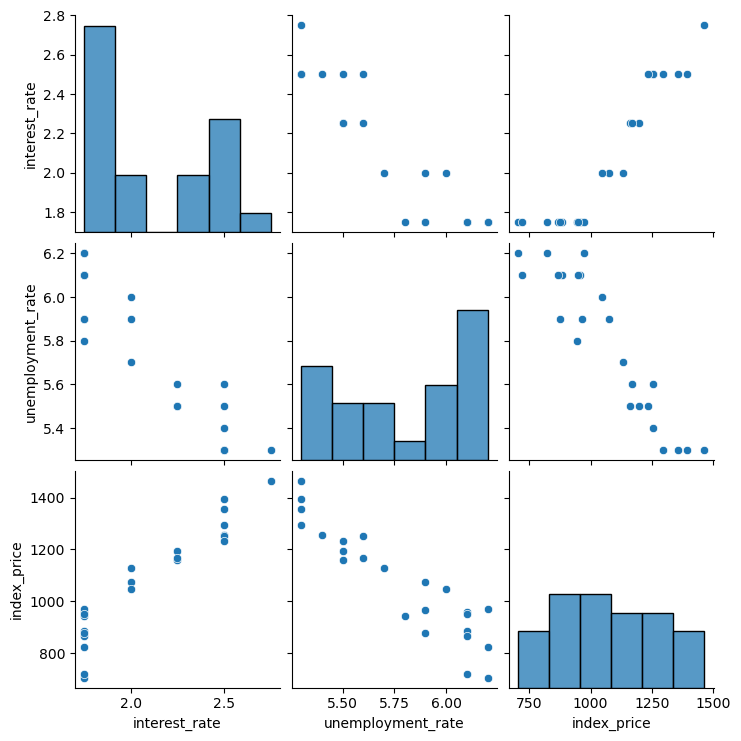

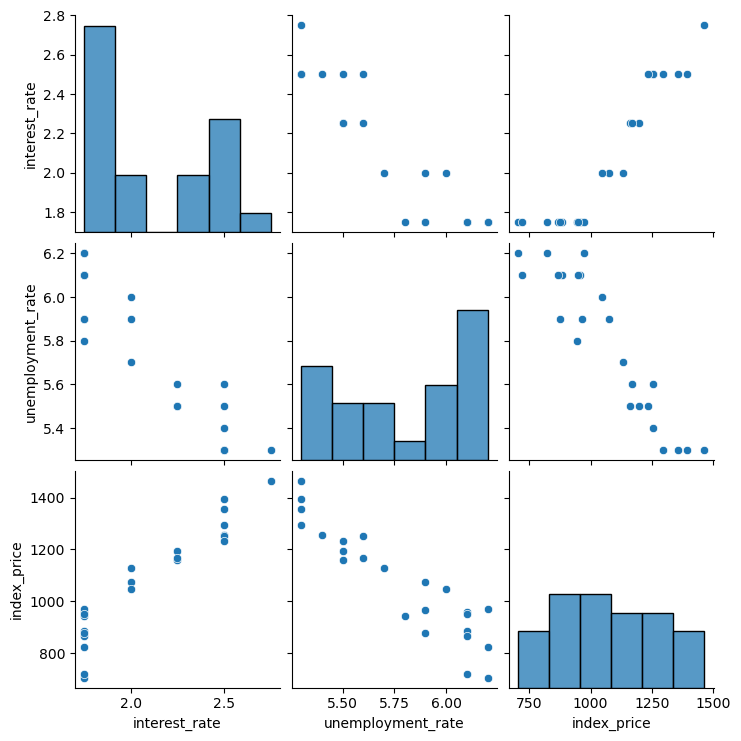

In [9]:
#visualization
sns.pairplot(df_index)
plt.show()


In [10]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


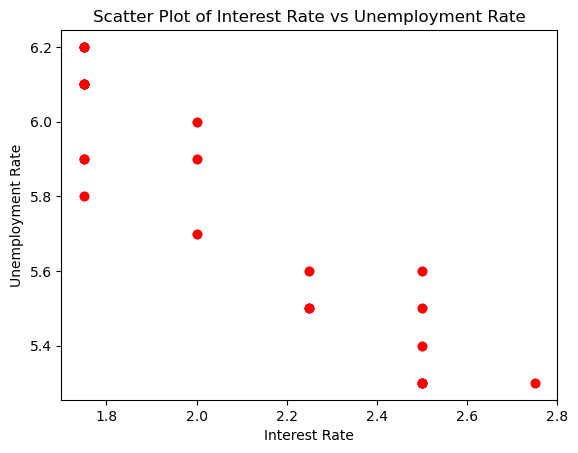

In [13]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Scatter Plot of Interest Rate vs Unemployment Rate')
plt.show()

In [18]:
#get independent and depenedent features
X=df_index[['interest_rate','unemployment_rate']]
y=df_index['index_price']


In [19]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [ ]:
#Train text split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


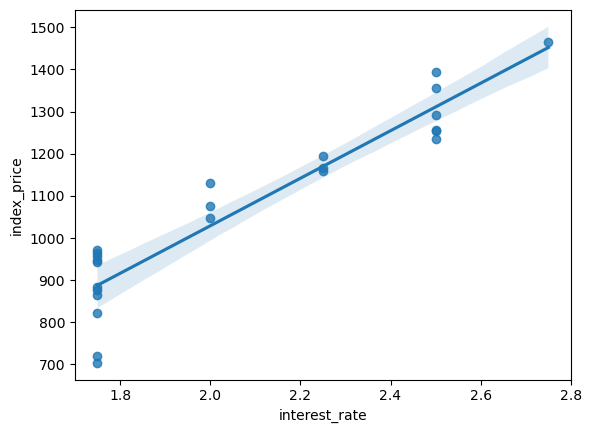

In [23]:
sns.regplot(x='interest_rate',y='index_price',data=df_index)
plt.show()

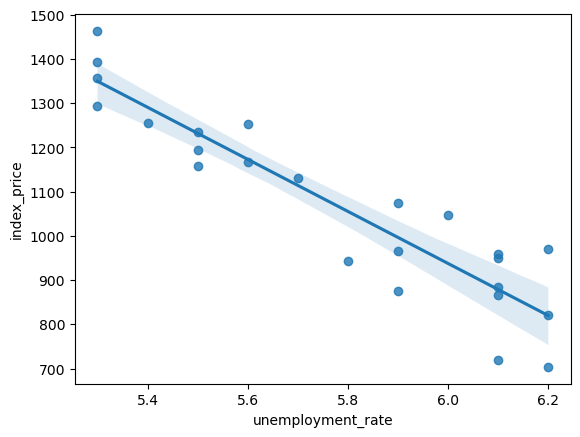

In [24]:
sns.regplot(x='unemployment_rate',y='index_price',data=df_index)
plt.show()

In [25]:

#standard scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [26]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [28]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [29]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(model,X_train,y_train,scoring='neg_mean_squared_error',cv=3)


In [32]:
import numpy as np
np.mean(validation_score)

np.float64(-5914.828180162388)

In [33]:
#precition
y_pred=model.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [ ]:
#Performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error
print('MSE:',mean_squared_error(y_test,y_pred))
print('MAE:',mean_absolute_error(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))

MSE: 5793.762887712579
R2 Score: 0.8278978091457142
MAE: 59.935781523235526
RMSE: 76.11677139574812


In [37]:

from sklearn.metrics import r2_score
print('R2 Score:',r2_score(y_test,y_pred))

R2 Score: 0.8278978091457142


ASSUMPTIONS

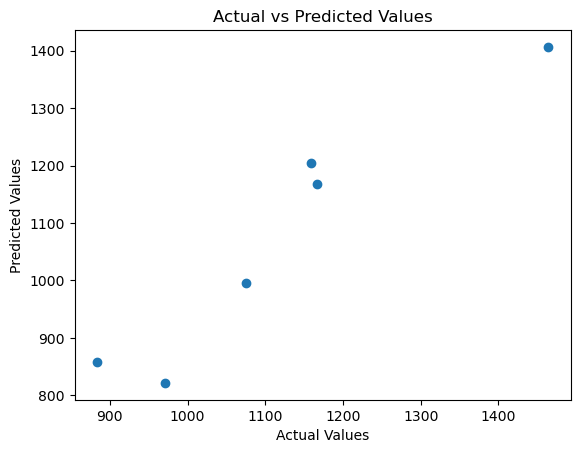

In [40]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

plt.show()

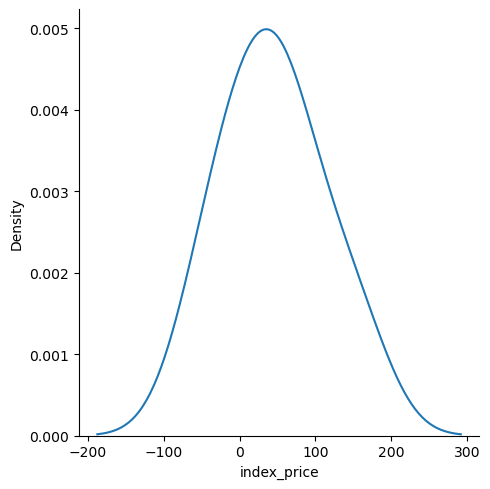

In [44]:
residuals=y_test-y_pred
sns.displot(residuals, kind='kde')
plt.show()

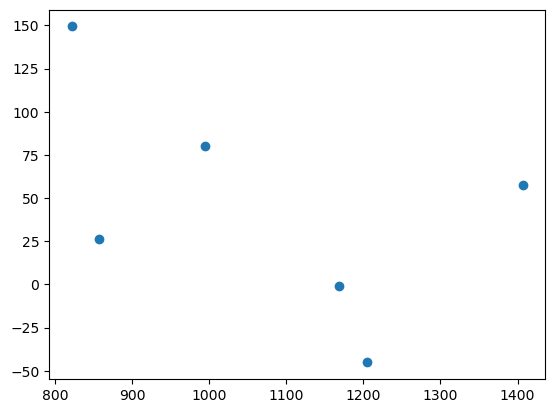

In [45]:
plt.scatter(y_pred,residuals)
plt.show()

In [46]:
print(model.coef_)

[  88.27275507 -116.25716066]
